In [1]:
import pandas as pd
from src import*
import joblib
from pmdarima.model_selection import RollingForecastCV

In [2]:
df_train = pd.read_csv('../data/processed/train, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv')
df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv')

In [3]:
depths = [0,5,10]
cv = RollingForecastCV(h = 365,step = 365, initial = 365 * 2)
for i in range(len(depths)):
    depth = depths[i]
    train = df_train[f'48-1 ({depth})']
    pipe = grid_search_cv(train, 0, range(0, 6), [0], [1,2,3,5,7,10], cv)
    joblib.dump(pipe, f"models/arima_cv_{depth}.pkl")

Best Model =  ARIMA(4,0,0)(0,0,0)[0] intercept, k = 2


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best Model =  ARIMA(5,0,0)(0,0,0)[0] intercept, k = 1


C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best Model =  ARIMA(0,0,0)(0,0,0)[0] intercept, k = 1


Pipeline(steps=[('fourier', FourierFeaturizer(k=2, m=365)),
                ('arima', ARIMA(maxiter=1000, order=(4, 0, 0)))])


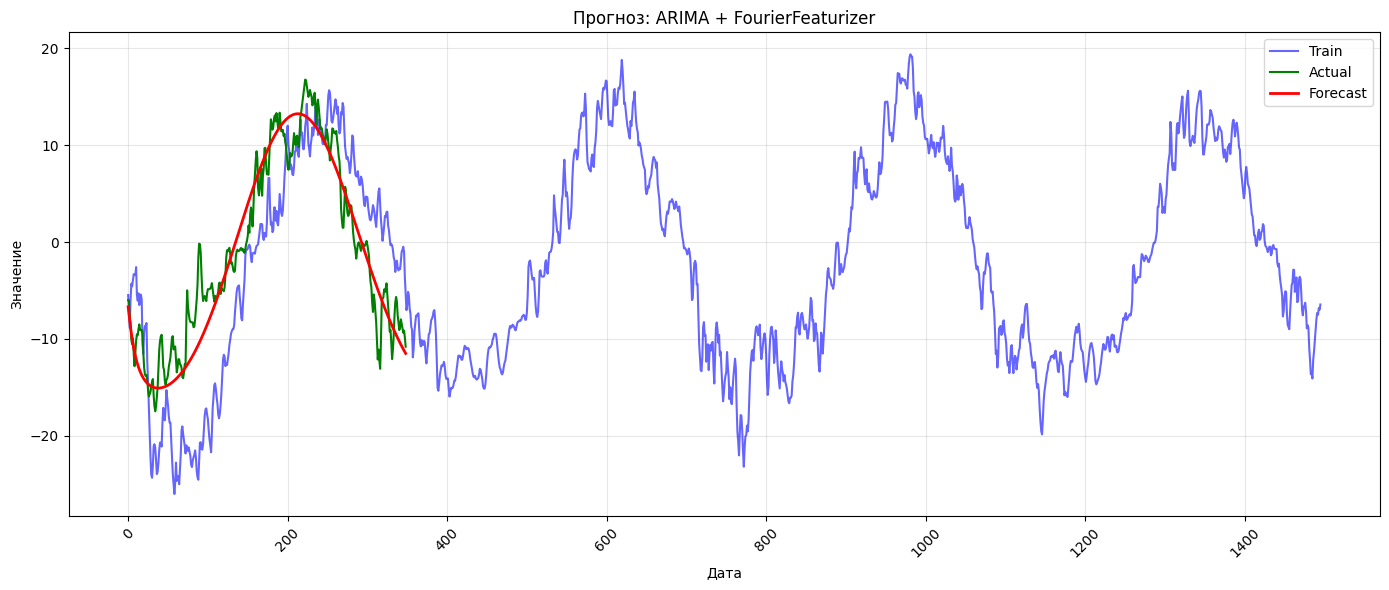


MAE: 2.19
RMSE: 2.77
Pipeline(steps=[('fourier', FourierFeaturizer(k=1, m=365)),
                ('arima', ARIMA(maxiter=1000, order=(5, 0, 0)))])


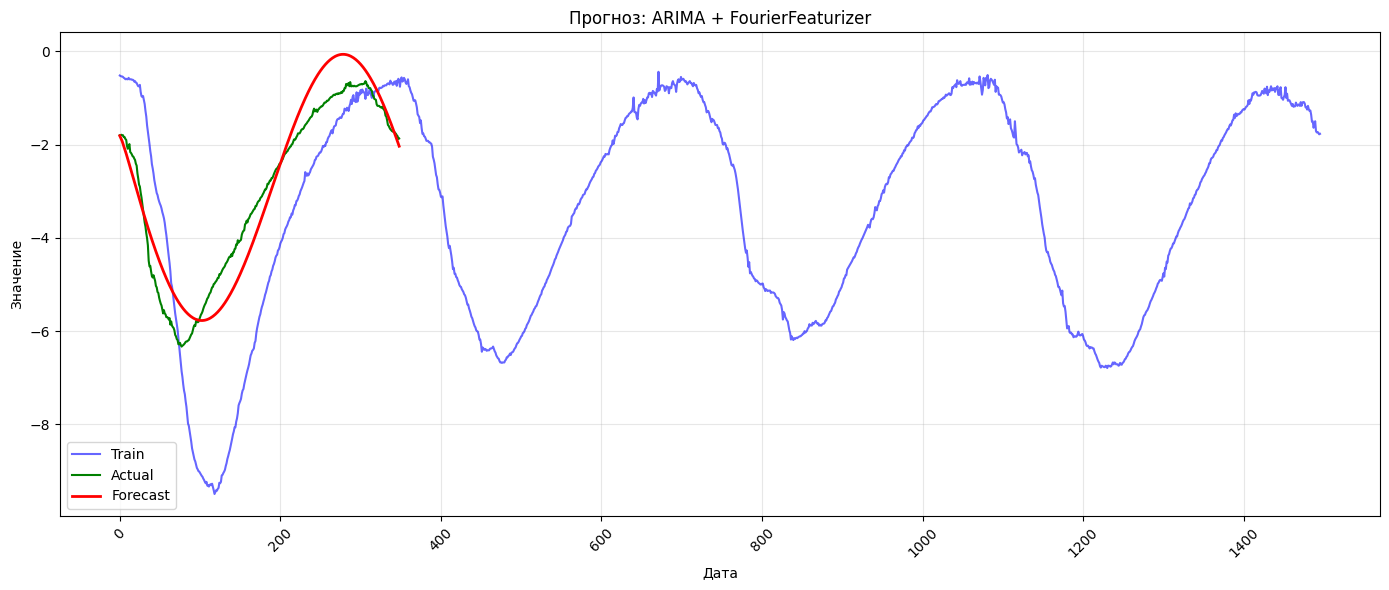


MAE: 0.50
RMSE: 0.57
Pipeline(steps=[('fourier', FourierFeaturizer(k=1, m=365)),
                ('arima', ARIMA(maxiter=1000, order=(0, 0, 0)))])


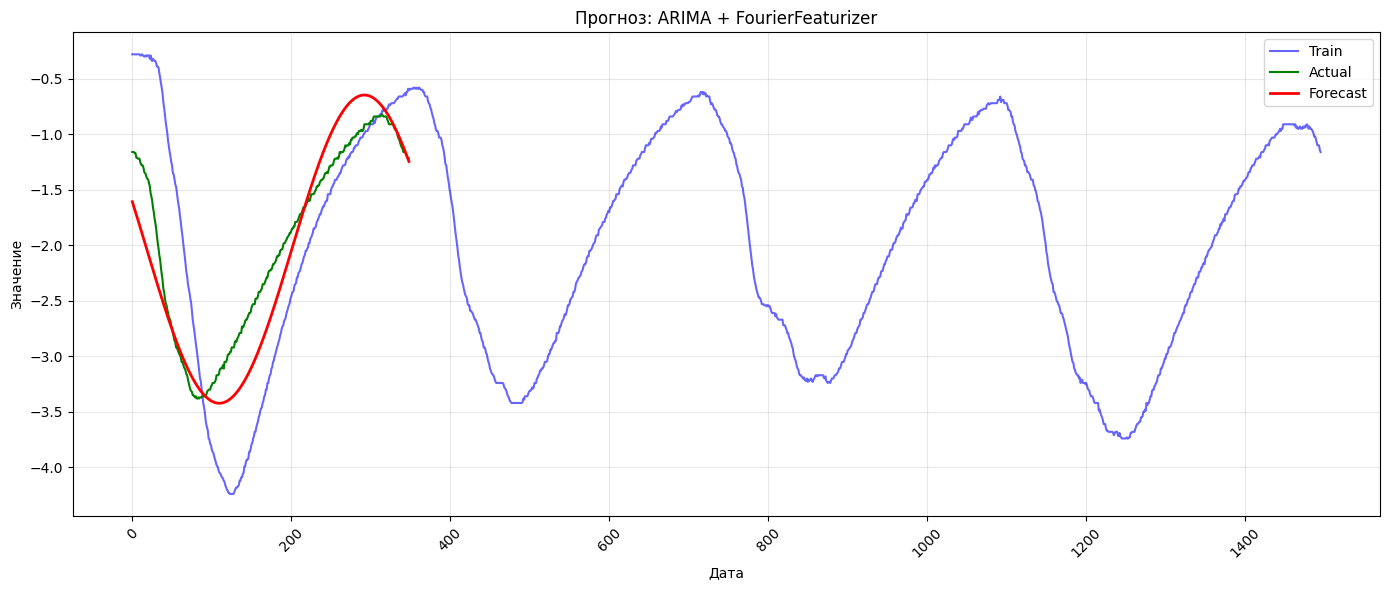


MAE: 0.26
RMSE: 0.32


In [4]:
depths = [0, 5, 10]
for depth in depths:
    train = df_train[f'48-1 ({depth})']
    test = df_test[f'48-1 ({depth})']
    pipe = joblib.load(f"models/arima_cv_{depth}.pkl")
    print(pipe)

    forecast = pipe.predict(n_periods=len(test))
    plot_forecast(train, test, forecast)
    print_metrics(forecast, test)